In [1]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO

from ilipy import Session
from ilipy.database import DistanceCorrelation
from ilipy import TrackIndex, OdometerTicks

inspection_id = "0A49KLT3B7Y"
num_tracks = 22
environment = "prod"
model_detection_threshold = 0.99

id_surface_fld = "s3://dv-ilit0008/track_runs/0A49KLT3B7Y/ili_ml_surface/v1.2/"

In [26]:
def download_parquet_from_s3(bucket_name, s3_key, local_path=None):
    """
    Download a parquet file from S3 and optionally save locally or return as DataFrame
    
    Args:
        bucket_name: S3 bucket name
        s3_key: S3 key (path) for the file
        local_path: Optional local file path to save the file. If None, returns DataFrame
        
    Returns:
        DataFrame if local_path is None, otherwise saves file locally and returns file path
    """
    s3_client = boto3.client('s3')
    
    try:
        # Download file from S3
        response = s3_client.get_object(Bucket=bucket_name, Key=s3_key)
        
        if local_path:
            # Save to local file
            with open(local_path, 'wb') as f:
                f.write(response['Body'].read())
            print(f"File downloaded and saved to: {local_path}")
            return local_path
        else:
            # Return as DataFrame
            parquet_buffer = BytesIO(response['Body'].read())
            df = pd.read_parquet(parquet_buffer)
            print(f"Downloaded DataFrame with {len(df)} rows from s3://{bucket_name}/{s3_key}")
            return df
            
    except Exception as e:
        print(f"Error downloading file: {e}")
        return None


In [ ]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

bucket_name = "dv-ilit0008"   

s3_key = f"track_runs/{inspection_id}/ili_ml_surface/"
download_s3_folder(bucket_name, s3_key, f"./data-files/insp_{inspection_id}_ml_surface")

In [2]:
import numpy as np

def ransac_line_fit(x, y, n_iters=500, distance_threshold=0.005, min_inlier_ratio=0.5, random_state=None):
    """
    Fit a robust line y = m x + b to 1D data (x, y) using RANSAC.

    Args:
        x, y: 1D arrays of the same length.
        n_iters: number of RANSAC iterations.
        distance_threshold: max perpendicular distance (in y units) to count a point as an inlier.
        min_inlier_ratio: early-stop if a model has this fraction of inliers.
        random_state: optional int for reproducibility.

    Returns:
        m, b, inlier_mask
        where:
          y ≈ m * x + b
          inlier_mask is a boolean array of same length as x/y.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    assert x.shape == y.shape
    n_points = x.size

    rng = np.random.default_rng(random_state)

    best_m, best_b = None, None
    best_inlier_mask = None
    best_inlier_count = 0

    # Helper: fit line from two points
    def line_from_points(x1, y1, x2, y2):
        if x2 == x1:
            # vertical line -> we handle this by skipping that sample
            return None, None
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        return m, b

    for _ in range(n_iters):
        # 1) Sample two distinct points
        idx = rng.choice(n_points, size=2, replace=False)
        x1, y1 = x[idx[0]], y[idx[0]]
        x2, y2 = x[idx[1]], y[idx[1]]

        m, b = line_from_points(x1, y1, x2, y2)
        if m is None:
            continue  # skip vertical-line degeneracy

        # 2) Compute perpendicular distance of all points to this line
        # Line: y = m x + b
        # Distance in y direction is |y - (m x + b)|
        # (for small slopes this is fine; for general case we can normalize)
        y_pred = m * x + b
        residuals = np.abs(y - y_pred)

        inlier_mask = residuals < distance_threshold
        inlier_count = np.count_nonzero(inlier_mask)

        # 3) Keep best model
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_m, best_b = m, b
            best_inlier_mask = inlier_mask

            # Early stop if we already explain most points
            if inlier_count >= min_inlier_ratio * n_points:
                break

    if best_inlier_mask is None:
        raise RuntimeError("RANSAC failed to find a valid model")

    # 4) Refit line using only inliers (ordinary least squares)
    x_in = x[best_inlier_mask]
    y_in = y[best_inlier_mask]

    # [m, b] = argmin ||y - (m x + b)||
    A = np.column_stack([x_in, np.ones_like(x_in)])
    m_refined, b_refined = np.linalg.lstsq(A, y_in, rcond=None)[0]

    return m_refined, b_refined, best_inlier_mask

def add_curvature_columns(df):
    """
    For each row in df, take 801 columns (df.iloc[:, 4:-1]), 
    compute global circle curvature and RANSAC line fit metrics.
    """
    feature_cols = df.columns[4:-1]
    n_points = len(feature_cols)
    x = np.arange(n_points)
    
    # Extract all y values as a 2D numpy array (rows x points)
    y_matrix = df[feature_cols].values.astype(float)
    
    # Initialize result lists
    ransac_slopes = []
    ransac_intercepts = []
    ransac_inlier_counts = []
    ransac_inlier_ratios = []
    
    print(f"Processing {len(df)} rows with {n_points} points each...")
    
    for i in range(len(df)):
        y = y_matrix[i]
    
        
        # RANSAC line fit
        try:
            m, b, inlier_mask = ransac_line_fit(
                x, y,
                n_iters=500,
                distance_threshold=0.005,
                min_inlier_ratio=0.7,
                random_state=0
            )
            inlier_count = np.count_nonzero(inlier_mask)
            inlier_ratio = inlier_count / n_points
            
            ransac_slopes.append(m)
            ransac_intercepts.append(b)
            ransac_inlier_counts.append(inlier_count)
            ransac_inlier_ratios.append(inlier_ratio)
        except Exception as e:
            ransac_slopes.append(np.nan)
            ransac_intercepts.append(np.nan)
            ransac_inlier_counts.append(0)
            ransac_inlier_ratios.append(0.0)
            
        if (i + 1) % 100 == 0:
            print(f"  Processed {i + 1}/{len(df)} rows")
    
    # Create result dataframe
    result_df = df.drop(columns=feature_cols).copy()

    
    # Add RANSAC line fit columns
    result_df['ransac_slope'] = ransac_slopes
    result_df['ransac_intercept'] = ransac_intercepts
    result_df['ransac_inlier_count'] = ransac_inlier_counts
    result_df['ransac_inlier_ratio'] = ransac_inlier_ratios
    

    return result_df

In [32]:
def add_view_distances(df, dist_corr, track_col='track_id', start_odo_col='start_odometer_tick', end_odo_col='end_odometer_tick'):
    """
    Add view_distance_start and view_distance_stop columns to DataFrame
    
    Args:
        df: DataFrame with odometer tick columns
        dist_corr: DistanceCorrelation object from ilipy
        track_col: column name containing track IDs
        start_odo_col: column name containing start odometer ticks
        end_odo_col: column name containing end odometer ticks
    
    Returns:
        DataFrame with added view_distance_start and view_distance_stop columns
    """
    if df is None or len(df) == 0:
        return df
    
    df = df.copy()
    counter = 0
    
    # Initialize new columns
    df['view_distance_start'] = np.nan
    df['view_distance_stop'] = np.nan
    
    # Process each row
    for idx, row in df.iterrows():
        try:
            track_id = int(row[track_col])
            start_odo = int(row[start_odo_col])
            end_odo = int(row[end_odo_col])
            
            # Get view distances
            start_vd = dist_corr.get_view_distance_from_odometer_ticks(
                TrackIndex(track_id), 
                OdometerTicks(start_odo)
            ).value
            
            end_vd = dist_corr.get_view_distance_from_odometer_ticks(
                TrackIndex(track_id), 
                OdometerTicks(end_odo)
            ).value
            if start_vd == end_vd and start_odo != end_odo:
                print(f"Warning: start and end view distances are equal for row {idx}")
                counter += 1
            df.loc[idx, 'view_distance_start'] = start_vd
            df.loc[idx, 'view_distance_stop'] = end_vd
            
        except Exception as e:
            print(f"Error processing row {idx}: {e}")
            continue
    print(counter)
    return df

In [42]:
session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

bucket_name = "dent-dev"
num_tracks = 22
bookmarks_dfs = []
for track_idx in range(num_tracks):
    s3_key = f"dent_bookmarks/UltrasoundDent_bookmarks_{inspection_id}_track_{track_idx}.parquet"
    df = download_parquet_from_s3(bucket_name, s3_key)
    if df is not None:
        print(f"Downloaded DataFrame shape: {df.shape}")
        processed_df = add_view_distances(df, dist_corr)
        bookmarks_dfs.append(processed_df)
bookmarks_dfs = pd.concat(bookmarks_dfs, ignore_index=True)
display(bookmarks_dfs)

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8080, Concurrent Connections: 1
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8080, Concurrent Connections: 1
RestApi.cpp(72): ApiService Ping Response (http://storage-dvv-01.darkvision.local:8080) : 200, 24ms
RestApi.cpp(72): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8080) : 200, 142ms
PySession.cpp(84): Initialized with inspection: 0A49KLT3B7Y
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8080, Concurrent Connections: 3
PigSpatialModel.cpp(308): vehicle 4 -> disk 5 -> FrontSlot has a track assignm

,inspection_id,frame_range,clip_id,track_id,start_frame,end_frame,sequence_length,frame_span,num_detections,start_timer_tick,...,timer_span,start_odometer_tick,end_odometer_tick,odometer_span,avg_confidence,max_confidence,min_confidence,confidence_std,view_distance_start,view_distance_stop
0,0A49KLT3B7Y,0_1028,01-000-11YWD5E5,0,0,1028,1029,1029,1029,78306722,...,73979,46536,61956,15420,0.9964,0.9973,0.9915,0.0010,2.207403,3.749692
1,0A49KLT3B7Y,10120519_10120703,01-000-11YWD5E5,0,10120519,10120703,185,185,185,318139302,...,4345,153616426,153619231,2805,0.9926,0.9937,0.9904,0.0009,15359.193165,15359.473658
2,0A49KLT3B7Y,10120739_10121083,01-000-11YWD5E5,0,10120739,10121083,345,345,345,318144480,...,8116,153619771,153625021,5250,0.9922,0.9944,0.9902,0.0009,15359.527665,15360.052752
3,0A49KLT3B7Y,10121094_10121433,01-000-11YWD5E5,0,10121094,10121433,340,340,340,318152851,...,7999,153625186,153630346,5160,0.9918,0.9932,0.9903,0.0007,15360.069276,15360.585361
4,0A49KLT3B7Y,10121444_10122013,01-000-11YWD5E5,0,10121444,10122013,570,570,570,318161102,...,13318,153630511,153639111,8600,0.9915,0.9932,0.9901,0.0006,15360.601864,15361.461779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12831,0A49KLT3B7Y,9564284_9564323,01-021-11YWDR6A,21,9564284,9564323,40,40,40,305019453,...,933,145104421,145105021,600,0.9907,0.9914,0.9900,0.0005,14507.056116,14507.116151
12832,0A49KLT3B7Y,9564374_9564888,01-021-11YWDR6A,21,9564374,9564888,515,515,515,305021597,...,12120,145105801,145113596,7795,0.9915,0.9930,0.9902,0.0007,14507.194146,14507.973610
12833,0A49KLT3B7Y,9574989_9575208,01-021-11YWDR6A,21,9574989,9575208,220,220,220,305272949,...,5153,145268176,145271506,3330,0.9911,0.9923,0.9901,0.0006,14523.430731,14523.763719
12834,0A49KLT3B7Y,9575239_9575513,01-021-11YWDR6A,21,9575239,9575513,275,275,275,305278845,...,6463,145271986,145276156,4170,0.9924,0.9939,0.9901,0.0010,14523.811735,14524.228833


In [44]:
bookmarks_dfs = bookmarks_dfs[bookmarks_dfs['start_odometer_tick'] != bookmarks_dfs['end_odometer_tick']]
display(bookmarks_dfs)

,inspection_id,frame_range,clip_id,track_id,start_frame,end_frame,sequence_length,frame_span,num_detections,start_timer_tick,...,timer_span,start_odometer_tick,end_odometer_tick,odometer_span,avg_confidence,max_confidence,min_confidence,confidence_std,view_distance_start,view_distance_stop
0,0A49KLT3B7Y,0_1028,01-000-11YWD5E5,0,0,1028,1029,1029,1029,78306722,...,73979,46536,61956,15420,0.9964,0.9973,0.9915,0.0010,2.207403,3.749692
1,0A49KLT3B7Y,10120519_10120703,01-000-11YWD5E5,0,10120519,10120703,185,185,185,318139302,...,4345,153616426,153619231,2805,0.9926,0.9937,0.9904,0.0009,15359.193165,15359.473658
2,0A49KLT3B7Y,10120739_10121083,01-000-11YWD5E5,0,10120739,10121083,345,345,345,318144480,...,8116,153619771,153625021,5250,0.9922,0.9944,0.9902,0.0009,15359.527665,15360.052752
3,0A49KLT3B7Y,10121094_10121433,01-000-11YWD5E5,0,10121094,10121433,340,340,340,318152851,...,7999,153625186,153630346,5160,0.9918,0.9932,0.9903,0.0007,15360.069276,15360.585361
4,0A49KLT3B7Y,10121444_10122013,01-000-11YWD5E5,0,10121444,10122013,570,570,570,318161102,...,13318,153630511,153639111,8600,0.9915,0.9932,0.9901,0.0006,15360.601864,15361.461779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12831,0A49KLT3B7Y,9564284_9564323,01-021-11YWDR6A,21,9564284,9564323,40,40,40,305019453,...,933,145104421,145105021,600,0.9907,0.9914,0.9900,0.0005,14507.056116,14507.116151
12832,0A49KLT3B7Y,9564374_9564888,01-021-11YWDR6A,21,9564374,9564888,515,515,515,305021597,...,12120,145105801,145113596,7795,0.9915,0.9930,0.9902,0.0007,14507.194146,14507.973610
12833,0A49KLT3B7Y,9574989_9575208,01-021-11YWDR6A,21,9574989,9575208,220,220,220,305272949,...,5153,145268176,145271506,3330,0.9911,0.9923,0.9901,0.0006,14523.430731,14523.763719
12834,0A49KLT3B7Y,9575239_9575513,01-021-11YWDR6A,21,9575239,9575513,275,275,275,305278845,...,6463,145271986,145276156,4170,0.9924,0.9939,0.9901,0.0010,14523.811735,14524.228833


In [ ]:
import glob
import re
from collections import defaultdict

def merge_surface_curvature_to_dents(dent_df, surface_base_path):
    """
    Merge surface curvature data into dent dataframe based on track_id and frame ranges.
    Optimized version with batch processing and reduced file I/O.
    Filters surface data before computing curvature calculations.
    Computes RANSAC line fit summary statistics directly without storing lists.
    
    Args:
        dent_df: DataFrame with dent bookmarks containing track_id, start_frame, end_frame
        surface_base_path: Base path to surface data files
    
    Returns:
        DataFrame with added summary statistics (no lists stored)
    """
    if dent_df is None or len(dent_df) == 0:
        return dent_df
    
    dent_df = dent_df.copy()
    
    # Initialize summary statistics columns only
    dent_df['ransac_inlier_ratio_mean'] = np.nan
    dent_df['ransac_inlier_ratio_median'] = np.nan
    dent_df['ransac_inlier_ratio_min'] = np.nan



    # Group dents by track_id for batch processing
    dents_by_track = defaultdict(list)
    for idx, row in dent_df.iterrows():
        dents_by_track[row['track_id']].append({
            'idx': idx,
            'start_frame': row['start_frame'],
            'end_frame': row['end_frame']
        })
    
    # Process each track
    for track_id, dent_list in dents_by_track.items():
        track_str = f"track_{track_id:02d}"
        track_path = f"{surface_base_path}/v1.2/{track_str}/**/frames_*.parquet"
        
        # Find all parquet files for this track
        parquet_files = glob.glob(track_path, recursive=True)
        
        # Parse file metadata once
        file_metadata = []
        for parquet_file in parquet_files:
            match = re.search(r'frames_(\d+)_(\d+)_\d+\.parquet', parquet_file)
            if match:
                file_metadata.append({
                    'path': parquet_file,
                    'start': int(match.group(1)),
                    'end': int(match.group(2))
                })
        
        # Sort files by start frame for efficient searching
        file_metadata.sort(key=lambda x: x['start'])
        
        # For each file, find all dents that overlap with it
        for file_info in file_metadata:
            file_start = file_info['start']
            file_end = file_info['end']
            
            # Find overlapping dents
            overlapping_dents = [
                d for d in dent_list
                if d['start_frame'] < file_end and d['end_frame'] >= file_start
            ]
            
            if not overlapping_dents:
                continue
            
            # Load file once for all overlapping dents
            try:
                print(f"Loading: {file_info['path']} for {len(overlapping_dents)} dents")
                surface_df = pd.read_parquet(file_info['path'])
                
                # Filter by track_id first
                surface_df = surface_df[surface_df['track_id'] == track_id]
                
                # Get frame range for all overlapping dents
                min_frame = min(d['start_frame'] for d in overlapping_dents)
                max_frame = max(d['end_frame'] for d in overlapping_dents)
                
                # Filter surface data to only frames needed by dents BEFORE curvature computation
                surface_df = surface_df[
                    (surface_df['frame'] >= min_frame) & 
                    (surface_df['frame'] <= max_frame)
                ]
                
                if len(surface_df) == 0:
                    print(f"  No matching frames in range [{min_frame}, {max_frame}]")
                    continue
                
                print(f"  Computing RANSAC metrics for {len(surface_df)} filtered frames...")
                # Now compute RANSAC metrics only on filtered data
                surface_df = add_curvature_columns(surface_df)
                
                # Process each overlapping dent
                for dent in overlapping_dents:
                    mask = (
                        (surface_df['frame'] >= dent['start_frame']) & 
                        (surface_df['frame'] <= dent['end_frame'])
                    )
                    matching_surface = surface_df[mask]
                    
                    if len(matching_surface) > 0:
                        # Compute statistics directly from matching data
                        inlier_ratios = matching_surface['ransac_inlier_ratio'].values
                        slopes = matching_surface['ransac_slope'].values
                        
                        # Remove NaN values
                        valid_ratios = inlier_ratios[~np.isnan(inlier_ratios)]
                        valid_slopes = slopes[~np.isnan(slopes)]
                        
                        if len(valid_ratios) > 0:
                            dent_df.at[dent['idx'], 'ransac_inlier_ratio_mean'] = np.mean(valid_ratios)
                            dent_df.at[dent['idx'], 'ransac_inlier_ratio_median'] = np.median(valid_ratios)
                            dent_df.at[dent['idx'], 'ransac_inlier_ratio_min'] = np.min(valid_ratios)
                        
                        
            except Exception as e:
                print(f"Error loading {file_info['path']}: {e}")
                continue
    
    print(f"\nMerged curvature data for {len(dent_df)} dent records")
    print(f"Added RANSAC line fit summary statistics")
    
    return dent_df

# Usage:
surface_base_path = f"./data-files/insp_{inspection_id}_ml_surface"
merged_dents = merge_surface_curvature_to_dents(bookmarks_dfs, surface_base_path)

# Display key metrics
display(merged_dents)

In [ ]:
#merged_dents.to_parquet(f"./data-files/insp_{inspection_id}_refined_dents_with_surface.parquet", index=False)

In [49]:
merged_dents = pd.read_parquet(f"./data-files/insp_{inspection_id}_refined_dents_with_surface.parquet")

In [51]:
merged_dents=merged_dents[merged_dents['start_odometer_tick'] != merged_dents['end_odometer_tick'] ]
display(merged_dents)

,inspection_id,frame_range,clip_id,track_id,start_frame,end_frame,sequence_length,frame_span,num_detections,start_timer_tick,...,odometer_span,avg_confidence,max_confidence,min_confidence,confidence_std,view_distance_start,view_distance_stop,ransac_inlier_ratio_mean,ransac_inlier_ratio_median,ransac_inlier_ratio_min
0,0A49KLT3B7Y,0_1028,01-000-11YWD5E5,0,0,1028,1029,1029,1029,78306722,...,15420,0.9964,0.9973,0.9915,0.0010,2.207403,3.749692,0.743945,0.740068,0.649262
1,0A49KLT3B7Y,10120519_10120703,01-000-11YWD5E5,0,10120519,10120703,185,185,185,318139302,...,2805,0.9926,0.9937,0.9904,0.0009,15359.193165,15359.473658,0.763886,0.745743,0.691260
2,0A49KLT3B7Y,10120739_10121083,01-000-11YWD5E5,0,10120739,10121083,345,345,345,318144480,...,5250,0.9922,0.9944,0.9902,0.0009,15359.527665,15360.052752,0.761460,0.752554,0.675369
3,0A49KLT3B7Y,10121094_10121433,01-000-11YWD5E5,0,10121094,10121433,340,340,340,318152851,...,5160,0.9918,0.9932,0.9903,0.0007,15360.069276,15360.585361,0.744588,0.735528,0.658343
4,0A49KLT3B7Y,10121444_10122013,01-000-11YWD5E5,0,10121444,10122013,570,570,570,318161102,...,8600,0.9915,0.9932,0.9901,0.0006,15360.601864,15361.461779,0.773666,0.766175,0.654938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12831,0A49KLT3B7Y,9564284_9564323,01-021-11YWDR6A,21,9564284,9564323,40,40,40,305019453,...,600,0.9907,0.9914,0.9900,0.0005,14507.056116,14507.116151,0.813961,0.808173,0.727582
12832,0A49KLT3B7Y,9564374_9564888,01-021-11YWDR6A,21,9564374,9564888,515,515,515,305021597,...,7795,0.9915,0.9930,0.9902,0.0007,14507.194146,14507.973610,0.829882,0.835414,0.700341
12833,0A49KLT3B7Y,9574989_9575208,01-021-11YWDR6A,21,9574989,9575208,220,220,220,305272949,...,3330,0.9911,0.9923,0.9901,0.0006,14523.430731,14523.763719,0.806434,0.812145,0.700341
12834,0A49KLT3B7Y,9575239_9575513,01-021-11YWDR6A,21,9575239,9575513,275,275,275,305278845,...,4170,0.9924,0.9939,0.9901,0.0010,14523.811735,14524.228833,0.816296,0.820658,0.624291


## Visualize all detected frames

In [6]:
# from ilipy.beamformer import BfImageType
# from ilipyutils.beamforming import Beamformer
# FF_DEFAULTS = {
#     "angle_resolution_radians": np.deg2rad(0.025),
#     "radial_resolution_mm": 0.05,
#     "radial_range_mm": [15, 33],
#     "angle_range_radians": np.deg2rad([-11, 11]).tolist(),
# }
# beamformer = Beamformer(
#     session=session,
#     inspection_id=session.active_inspection.inspection_id,
#     clip=clip_ds,
# )
# vol = beamformer.beamform_data(
#     frame_range=(iframe, iframe + 1),
#     bf_type=BfImageType.InnerSurfaceDetect,
#     calc_circles=False,
#     bf_configs=FF_DEFAULTS,
# )

import os
from pathlib import Path
import matplotlib.pyplot as plt
from ilipy.beamformer import BfImageType
from ilipyutils.beamforming import Beamformer
from ilipy import Clip, ClipTypes


def visualize_bookmark_frames(bookmarks_df, session, output_folder="./bookmark_frames"):
    """
    Save beamformed images for all frames in bookmarks dataframe.
    
    Args:
        bookmarks_df: DataFrame with bookmark data containing track_id, start_frame, end_frame
        session: ilipy Session object
        output_folder: Path to save the frame images
    """
    # Create output folder if it doesn't exist
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Beamformer configuration
    FF_DEFAULTS = {
        "angle_resolution_radians": np.deg2rad(0.025),
        "radial_resolution_mm": 0.05,
        "radial_range_mm": [15, 33],
        "angle_range_radians": np.deg2rad([-11, 11]).tolist(),
    }
    

    print(f"Processing {len(bookmarks_df)} bookmarks...")
    clips = session.get_clips_by_type(ClipTypes.ChannelData)
    
    # Process each bookmark
    for idx, row in bookmarks_df.iterrows():
        track_id = int(row['track_id'])
        start_frame = int(row['start_frame'])
        end_frame = int(row['end_frame'])
        clip_id = str(row['clip_id'])
        clip = [clip for clip in clips if clip.clip_id==clip_id]
            # Initialize beamformer
        beamformer = Beamformer(
            session=session,
            inspection_id=inspection_id,
            clip=clip[0],
        )
    
        # Create subfolder for each bookmark
        bookmark_folder = output_path / f"bookmark_{idx}_track_{track_id:02d}"
        bookmark_folder.mkdir(exist_ok=True)
        
        print(f"Processing bookmark {idx}: track {track_id}, frames {start_frame}-{end_frame}")
        
        # Process frames in the range
        for frame in range(start_frame, end_frame + 1):
            try:
                # Beamform the frame
                vol = beamformer.beamform_data(
                    frame_range=(frame, frame + 1),
                    bf_type=BfImageType.InnerSurfaceDetect,
                    calc_circles=False,
                    bf_configs=FF_DEFAULTS,
                )
                
                # Create figure
                fig, ax = plt.subplots(figsize=(10, 8))
                
                # Display the beamformed image
                im = ax.imshow(vol[0], cmap='gray', aspect='auto')
                ax.set_title(f"Track {track_id}, Frame {frame}")
                ax.set_xlabel("Angle")
                ax.set_ylabel("Radial Distance")
                plt.colorbar(im, ax=ax, label="Intensity")
                
                # Save the figure
                output_file = bookmark_folder / f"frame_{frame:010d}.png"
                plt.savefig(output_file, dpi=150, bbox_inches='tight')
                plt.close(fig)
                
                print(f"  Saved frame {frame}")
                
            except Exception as e:
                print(f"  Error processing frame {frame}: {e}")
                continue
    
    print(f"\nAll frames saved to {output_folder}")

# Usage:
visualize_bookmark_frames(bookmarks_dfs, session, output_folder="./dent_us_frames_visualization2")

Processing 0 bookmarks...


AttributeError: 'list' object has no attribute 'iterrows'

In [ ]:
#bookmarks_dfs[np.floor(bookmarks_dfs['view_distance_start']).isin(arm_dents)]

In [ ]:

#bookmarks_dfs = bookmarks_dfs.query('frame_span <= 130')

In [56]:
def group_by_view_distance_bins(df, view_distance_col='view_distance_start', group_col='view_distance_group', bin_size=0.2):
    """
    Group DataFrame rows based on binned view_distance_start
    
    Args:
        df: DataFrame with view distance column
        view_distance_col: column name containing view distances
        group_col: name for the new grouping column
        bin_size: size of each bin (default 0.2)
    
    Returns:
        DataFrame with added grouping column
    """
    if df is None or len(df) == 0:
        return df
    
    df = df.copy()
    
    # Create grouping column based on binned view distance
    df[group_col] = (np.floor(df[view_distance_col] / bin_size) * bin_size).round(1)
    
    return df

def analyze_view_distance_groups(df, view_distance_col='view_distance_start', group_col='view_distance_group', bin_size=0.2):
    """
    Group by view distance bins and analyze the groups
    
    Args:
        df: DataFrame with view distances
        view_distance_col: column name containing view distances  
        group_col: name for the grouping column
        bin_size: size of each bin (default 0.2)
    
    Returns:
        tuple: (grouped_df, summary_stats)
    """
    # Add grouping column
    grouped_df = group_by_view_distance_bins(df, view_distance_col, group_col, bin_size)
    
    # Create summary statistics with track_id list
    agg_dict = {
        view_distance_col: ['count', 'min', 'max', 'mean'],
        'track_id': lambda x: list(x.unique())  # Keep list of unique track IDs
    }
    
    # Add view_distance_stop aggregations if column exists
    if 'view_distance_stop' in df.columns:
        agg_dict['view_distance_stop'] = ['min', 'max', 'mean']
    
    # Add other columns if they exist
    if 'avg_confidence' in df.columns:
        agg_dict['avg_confidence'] = ['mean', 'max', 'min']
    if 'sequence_length' in df.columns:
        agg_dict['sequence_length'] = ['mean', 'sum']
    
    # Perform the main aggregation without ransac_inlier_ratio_min
    summary_stats = grouped_df.groupby(group_col).agg(agg_dict)
    
    # Flatten column names
    new_columns = []
    for col in summary_stats.columns:
        if col[0] == 'track_id':
            new_columns.append('track_ids')
        else:
            new_columns.append(f'{col[0]}_{col[1]}')
    
    summary_stats.columns = new_columns
    summary_stats = summary_stats.reset_index()
    
    # Add ransac_inlier_ratio_min dictionary separately if column exists
    if 'ransac_inlier_ratio_min' in grouped_df.columns:
        ransac_dict = grouped_df.groupby(group_col).apply(
            lambda g: dict(zip(g['track_id'].values, g['ransac_inlier_ratio_min'].values))
        )
        summary_stats['ransac_inlier_ratio_min_by_track'] = summary_stats[group_col].map(ransac_dict)
    
    # Add count of unique tracks per group
    summary_stats['unique_tracks_count'] = summary_stats['track_ids'].apply(len)
    
    print(f"Created {len(summary_stats)} view distance groups (bin size: {bin_size})")
    print(f"Group range: {summary_stats[group_col].min()} to {summary_stats[group_col].max()}")
    
    return grouped_df, summary_stats


# Apply to your bookmarks data with 0.2 bin size
grouped_bookmarks, group_summary = analyze_view_distance_groups(merged_dents, bin_size=0.2)

print("View Distance Groups Summary:")
display(group_summary)

# Example: Show ransac ratios by track for first few groups
print("\nExample ransac_inlier_ratio_min_by_track (first 3 groups):")
for idx, row in group_summary.head(3).iterrows():
    print(f"\nGroup {row['view_distance_group']}:")
    print(f"  Track to Ratio mapping: {row['ransac_inlier_ratio_min_by_track']}")

Created 7034 view distance groups (bin size: 0.2)
Group range: 1.0 to 26304.8
View Distance Groups Summary:


/tmp/ipykernel_119219/2372749171.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ransac_dict = grouped_df.groupby(group_col).apply(


,view_distance_group,view_distance_start_count,view_distance_start_min,view_distance_start_max,view_distance_start_mean,track_ids,view_distance_stop_min,view_distance_stop_max,view_distance_stop_mean,avg_confidence_mean,avg_confidence_max,avg_confidence_min,sequence_length_mean,sequence_length_sum,ransac_inlier_ratio_min_by_track,unique_tracks_count
0,1.0,2,1.106755,1.170136,1.138445,"[5, 19]",1.317005,1.337572,1.327288,0.994550,0.9947,0.9944,127.000000,254,"{5: 0.677639046538025, 19: 0.7003405221339387}",2
1,1.2,2,1.238182,1.333112,1.285647,"[10, 21]",1.388628,2.654244,2.021436,0.992700,0.9942,0.9912,488.500000,977,"{10: 0.7037457434733257, 21: 0.5607264472190693}",2
2,1.4,6,1.452073,1.568376,1.507394,"[10, 16, 18]",1.458984,1.884136,1.611002,0.991533,0.9958,0.9900,70.333333,422,"{10: 0.7162315550510783, 16: 0.70261066969353,...",3
3,1.6,1,1.674857,1.674857,1.674857,[10],2.565338,2.565338,2.565338,0.992000,0.9920,0.9920,595.000000,595,{10: 0.7003405221339387},1
4,1.8,4,1.851006,1.951715,1.913847,"[2, 7]",1.938275,3.882211,2.433579,0.991350,0.9941,0.9901,350.750000,1403,"{2: 0.42224744608399545, 7: 0.7037457434733257}",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7029,26304.0,2,26304.093055,26304.107655,26304.100355,"[11, 15]",26304.128685,26304.234376,26304.181531,0.991650,0.9932,0.9901,55.000000,110,"{11: 0.3518728717366629, 15: 0.19977298524404086}",2
7030,26304.2,4,26304.218229,26304.385943,26304.293611,"[5, 9, 12]",26304.277029,26304.498076,26304.407166,0.992925,0.9948,0.9919,70.000000,280,"{5: 0.25539160045402953, 9: 0.2905788876276958...",3
7031,26304.4,2,26304.456238,26304.459202,26304.457720,"[6, 9]",26304.494553,26304.560288,26304.527421,0.991200,0.9918,0.9906,47.500000,95,"{6: 0.41316685584562995, 9: 0.40749148694665155}",2
7032,26304.6,1,26304.659468,26304.659468,26304.659468,[9],26304.717719,26304.717719,26304.717719,0.991200,0.9912,0.9912,40.000000,40,{9: 0.42338251986379116},1



Example ransac_inlier_ratio_min_by_track (first 3 groups):

Group 1.0:
  Track to Ratio mapping: {5: 0.677639046538025, 19: 0.7003405221339387}

Group 1.2:
  Track to Ratio mapping: {10: 0.7037457434733257, 21: 0.5607264472190693}

Group 1.4:
  Track to Ratio mapping: {10: 0.7162315550510783, 16: 0.70261066969353, 18: 0.6492622020431328}


In [57]:
# Filter for view_distance_start_count values 1, 2, or 3
filtered_groups = group_summary[group_summary['view_distance_start_count'].isin([1, 2, 3])]
print(f"Number of rows with view_distance_start_count in [1, 2, 3]: {len(filtered_groups)}")

# Show the filtered rows
display(filtered_groups)

# Or get the count for each individual group
for group_val in [1, 2, 3]:
    count = len(group_summary[group_summary['view_distance_start_count'] == group_val])
    print(f"view_distance_start_count = {group_val}: {count} rows")

# Alternative: Get total count directly
total_count = len(group_summary[group_summary['view_distance_start_count'].isin([1, 2, 3])])
print(f"Total rows with view_distance_start_count in [1, 2, 3]: {total_count}")






Number of rows with view_distance_start_count in [1, 2, 3]: 6371


,view_distance_group,view_distance_start_count,view_distance_start_min,view_distance_start_max,view_distance_start_mean,track_ids,view_distance_stop_min,view_distance_stop_max,view_distance_stop_mean,avg_confidence_mean,avg_confidence_max,avg_confidence_min,sequence_length_mean,sequence_length_sum,ransac_inlier_ratio_min_by_track,unique_tracks_count
0,1.0,2,1.106755,1.170136,1.138445,"[5, 19]",1.317005,1.337572,1.327288,0.994550,0.9947,0.9944,127.000000,254,"{5: 0.677639046538025, 19: 0.7003405221339387}",2
1,1.2,2,1.238182,1.333112,1.285647,"[10, 21]",1.388628,2.654244,2.021436,0.992700,0.9942,0.9912,488.500000,977,"{10: 0.7037457434733257, 21: 0.5607264472190693}",2
3,1.6,1,1.674857,1.674857,1.674857,[10],2.565338,2.565338,2.565338,0.992000,0.9920,0.9920,595.000000,595,{10: 0.7003405221339387},1
10,3.0,3,3.123797,3.197181,3.149589,"[4, 11, 13]",3.232823,3.749478,3.568699,0.992200,0.9944,0.9907,278.000000,834,"{4: 0.5845629965947786, 11: 0.7003405221339387...",3
11,3.2,1,3.251970,3.251970,3.251970,[20],3.360142,3.360142,3.360142,0.992600,0.9926,0.9926,75.000000,75,{20: 0.7003405221339387},1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7025,26303.2,3,26303.201012,26303.310614,26303.251089,"[2, 19, 21]",26303.209818,26303.384876,26303.289431,0.991867,0.9920,0.9916,23.333333,70,"{2: 0.34846765039727584, 19: 0.289443813847900...",3
7029,26304.0,2,26304.093055,26304.107655,26304.100355,"[11, 15]",26304.128685,26304.234376,26304.181531,0.991650,0.9932,0.9901,55.000000,110,"{11: 0.3518728717366629, 15: 0.19977298524404086}",2
7031,26304.4,2,26304.456238,26304.459202,26304.457720,"[6, 9]",26304.494553,26304.560288,26304.527421,0.991200,0.9918,0.9906,47.500000,95,"{6: 0.41316685584562995, 9: 0.40749148694665155}",2
7032,26304.6,1,26304.659468,26304.659468,26304.659468,[9],26304.717719,26304.717719,26304.717719,0.991200,0.9912,0.9912,40.000000,40,{9: 0.42338251986379116},1


view_distance_start_count = 1: 4090 rows
view_distance_start_count = 2: 1665 rows
view_distance_start_count = 3: 616 rows
Total rows with view_distance_start_count in [1, 2, 3]: 6371


In [58]:
def select_final_track_id(df, track_ids_col='track_ids', ransac_dict_col='ransac_inlier_ratio_min_by_track', final_col='track_id_final'):
    """
    Select final track ID based on specified rules.
    
    Args:
        df: DataFrame with track_ids column
        track_ids_col: column name containing list of track IDs
        ransac_dict_col: column name containing dictionary of track_id to ransac ratios
        final_col: name for the new final track ID column
    
    Returns:
        DataFrame with added final track ID column
    """
    if df is None or len(df) == 0:
        return df
    
    df = df.copy()
    
    final_track_ids = []
    
    for idx, row in df.iterrows():
        track_ids = row[track_ids_col]
        ransac_dict = row[ransac_dict_col] if ransac_dict_col in df.columns else {}
        
        if len(track_ids) == 1:
            # Single track - use it
            final_track_ids.append([track_ids[0]])
        
        elif len(track_ids) == 3:
            # Three tracks - select the one with lowest ransac_inlier_ratio_min
            if ransac_dict:
                # Find track with minimum ransac ratio
                min_track = min(track_ids, key=lambda tid: ransac_dict.get(tid, float('inf')))
                final_track_ids.append([min_track])
            else:
                # Fallback to middle track if no ransac data
                final_track_ids.append([sorted(track_ids)[1]])
        
        elif len(track_ids) == 2:
            # Two tracks - check if consecutive
            sorted_tracks = sorted(track_ids)
            if abs(sorted_tracks[0] - sorted_tracks[1]) == 1:
                # Consecutive - take the lower number
                final_track_ids.append([min(track_ids)])
            else:
                # Not consecutive - keep both
                final_track_ids.append(track_ids)
        
        else:
            # Other cases - keep None or the list
            final_track_ids.append(track_ids if len(track_ids) > 0 else None)
    
    df[final_col] = final_track_ids
    
    return df

# Apply to your filtered groups
final_grouped_bookmarks = select_final_track_id(filtered_groups)
display(final_grouped_bookmarks)

,view_distance_group,view_distance_start_count,view_distance_start_min,view_distance_start_max,view_distance_start_mean,track_ids,view_distance_stop_min,view_distance_stop_max,view_distance_stop_mean,avg_confidence_mean,avg_confidence_max,avg_confidence_min,sequence_length_mean,sequence_length_sum,ransac_inlier_ratio_min_by_track,unique_tracks_count,track_id_final
0,1.0,2,1.106755,1.170136,1.138445,"[5, 19]",1.317005,1.337572,1.327288,0.994550,0.9947,0.9944,127.000000,254,"{5: 0.677639046538025, 19: 0.7003405221339387}",2,"[5, 19]"
1,1.2,2,1.238182,1.333112,1.285647,"[10, 21]",1.388628,2.654244,2.021436,0.992700,0.9942,0.9912,488.500000,977,"{10: 0.7037457434733257, 21: 0.5607264472190693}",2,"[10, 21]"
3,1.6,1,1.674857,1.674857,1.674857,[10],2.565338,2.565338,2.565338,0.992000,0.9920,0.9920,595.000000,595,{10: 0.7003405221339387},1,[10]
10,3.0,3,3.123797,3.197181,3.149589,"[4, 11, 13]",3.232823,3.749478,3.568699,0.992200,0.9944,0.9907,278.000000,834,"{4: 0.5845629965947786, 11: 0.7003405221339387...",3,[4]
11,3.2,1,3.251970,3.251970,3.251970,[20],3.360142,3.360142,3.360142,0.992600,0.9926,0.9926,75.000000,75,{20: 0.7003405221339387},1,[20]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7025,26303.2,3,26303.201012,26303.310614,26303.251089,"[2, 19, 21]",26303.209818,26303.384876,26303.289431,0.991867,0.9920,0.9916,23.333333,70,"{2: 0.34846765039727584, 19: 0.289443813847900...",3,[21]
7029,26304.0,2,26304.093055,26304.107655,26304.100355,"[11, 15]",26304.128685,26304.234376,26304.181531,0.991650,0.9932,0.9901,55.000000,110,"{11: 0.3518728717366629, 15: 0.19977298524404086}",2,"[11, 15]"
7031,26304.4,2,26304.456238,26304.459202,26304.457720,"[6, 9]",26304.494553,26304.560288,26304.527421,0.991200,0.9918,0.9906,47.500000,95,"{6: 0.41316685584562995, 9: 0.40749148694665155}",2,"[6, 9]"
7032,26304.6,1,26304.659468,26304.659468,26304.659468,[9],26304.717719,26304.717719,26304.717719,0.991200,0.9912,0.9912,40.000000,40,{9: 0.42338251986379116},1,[9]


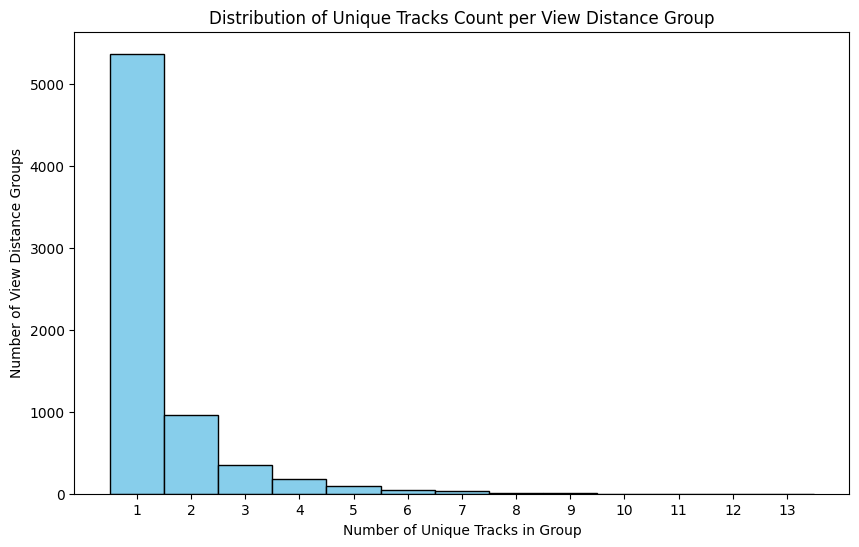

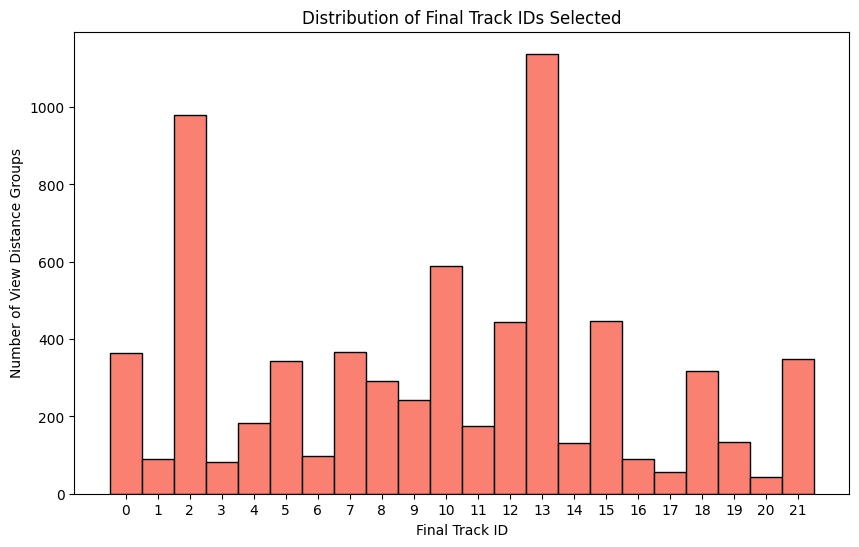

In [59]:
#plot the distrubution on unique_tracks_count
plt.figure(figsize=(10, 6))
plt.hist(group_summary['unique_tracks_count'], bins=range(1, group_summary['unique_tracks_count'].max() + 2), align='left', color='skyblue', edgecolor='black')
plt.xticks(range(1, group_summary['unique_tracks_count'].max() + 1))
plt.xlabel('Number of Unique Tracks in Group')
plt.ylabel('Number of View Distance Groups')    
plt.title('Distribution of Unique Tracks Count per View Distance Group')
plt.show()

#plot the distrubution on track_id_final
final_track_ids = final_grouped_bookmarks['track_id_final'].explode().dropna().astype(int)
plt.figure(figsize=(10, 6))
plt.hist(final_track_ids, bins=range(final_track_ids.min(), final_track_ids.max() + 2), align='left', color='salmon', edgecolor='black')
plt.xticks(range(final_track_ids.min(), final_track_ids.max() + 1))
plt.xlabel('Final Track ID')    
plt.ylabel('Number of View Distance Groups')
plt.title('Distribution of Final Track IDs Selected')
plt.show()


In [60]:
arm_dents =[17542.34922510133, 15100.020171205118, 22650.521588984826, 8005.051163523586, 1758.8292370739293, 20051.426239316646, 11761.222894815945, 23579.27213527145, 19078.72176126438, 11430.31797993651, 962.3722837421197, 22575.821014729776, 21303.57204320849, 14074.816406612117, 9978.566298548485, 19405.592821903865, 20612.422619697034, 6812.823397800676, 12656.067253844702, 1584.1983303053846, 25185.498062219405, 22647.800734789358, 6421.90090788972, 922.8997342608014, 20521.653043211256, 10957.849190601362, 19307.326811928186, 4937.796132463471, 18371.243325822525, 8543.590223557372, 2767.073590613183, 2288.8730356217125, 24817.620883885247, 21969.8737611737, 20482.97277935727, 17188.072005544946]

In [61]:
# Filter group_summary where view_distance_group is within 0.1 of any arm_dents value
def is_within_range(vd_group, arm_dents_list, tolerance=0.2):
    """Check if view_distance_group is within tolerance of any arm_dents value"""
    for arm_dent in arm_dents_list:
        if abs(vd_group - arm_dent) <= tolerance:
            return True
    return False

# Apply filter
filtered_group_summary = group_summary[
    group_summary['view_distance_group'].apply(
        lambda x: is_within_range(x, arm_dents, tolerance=0.2)
    )
]
display(filtered_group_summary)

,view_distance_group,view_distance_start_count,view_distance_start_min,view_distance_start_max,view_distance_start_mean,track_ids,view_distance_stop_min,view_distance_stop_max,view_distance_stop_mean,avg_confidence_mean,avg_confidence_max,avg_confidence_min,sequence_length_mean,sequence_length_sum,ransac_inlier_ratio_min_by_track,unique_tracks_count
575,922.8,1,922.892978,922.892978,922.892978,[15],922.929466,922.929466,922.929466,0.994100,0.9941,0.9941,25.000000,25,{15: 0.4188422247446084},1
576,962.2,1,962.269978,962.269978,962.269978,[6],962.306227,962.306227,962.306227,0.993400,0.9934,0.9934,25.000000,25,{6: 0.3757094211123723},1
907,2288.8,2,2288.937655,2288.943598,2288.940627,"[0, 21]",2288.964915,2288.966348,2288.965631,0.992700,0.9935,0.9919,17.500000,35,"{0: 0.5346197502837684, 21: 0.2883087400681044}",2
1109,2767.0,2,2767.048869,2767.071490,2767.060180,"[19, 20]",2767.109494,2767.116897,2767.113195,0.992900,0.9931,0.9927,35.000000,70,"{19: 0.3847900113507378, 20: 0.42565266742338254}",2
1518,4937.6,3,4937.774430,4937.791228,4937.783425,"[18, 19, 21]",4937.849868,4937.872745,4937.860887,0.992600,0.9928,0.9924,51.666667,155,"{18: 0.5096481271282634, 19: 0.455164585698070...",3
1963,6421.8,2,6421.842070,6421.890729,6421.866400,"[11, 12]",6421.904218,6421.962686,6421.933452,0.994100,0.9951,0.9931,45.000000,90,"{11: 0.5584562996594779, 12: 0.4097616345062429}",2
2027,6812.8,1,6812.851728,6812.851728,6812.851728,[9],6812.927190,6812.927190,6812.927190,0.993100,0.9931,0.9931,50.000000,50,{9: 0.6061293984108967},1
2173,8005.0,4,8005.029223,8005.170125,8005.102333,"[4, 10, 17]",8005.035191,8005.233354,8005.181833,0.991450,0.9927,0.9903,53.750000,215,"{4: 0.7003405221339387, 10: 0.5800227014755959...",3
2174,8005.2,7,8005.277105,8005.359185,8005.310336,"[3, 4, 5, 7, 17]",8005.298192,8007.008911,8005.594172,0.990757,0.9916,0.9903,190.000000,1330,"{3: 0.7003405221339387, 4: 0.70261066969353, 5...",5
2408,9978.6,2,9978.668447,9978.672722,9978.670584,"[5, 6]",9978.731413,9978.796505,9978.763959,0.993450,0.9949,0.9920,62.500000,125,"{5: 0.5221339387060159, 6: 0.3564131668558456}",2


## Upload anomalies

In [62]:
from ilipy import ClipTypes, Session, TrackIndex, ViewDistance
from ilipy.channeldata import ImageProfile
from ilipy.features import Bookmarks
from ilipyutils.ml_features.base import (get_ml_models_info_list, AnomalyStatus)
from ilipyutils.ml_features.insert import FeatureInsert, GeometryCubeParameters
from ili_custom_data.load_model import ModelDataLoader
from ilipy.database import DistanceCorrelation
from ilipyutils.ml_features.overlap import (
    AnomalyOverlapManager,
    OverlapAction,
    OverlapPolicy,
)


session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)
bookmarks_interface = Bookmarks(connector=session.database_connector)
latest_model = ModelDataLoader.get_latest_model()

overlap_policy = OverlapPolicy(
    action=OverlapAction.TAG_DUPLICATE,
    min_overlap_iou=0.1,
)
anomaly_overlap_manager = AnomalyOverlapManager(
    overlap_policy=overlap_policy,
    session=session,
    bookmarks_interface=bookmarks_interface,
)
feature_insert = FeatureInsert(
    session=session,
    bookmarks_interface=bookmarks_interface,
    anomaly_overlap_manager=anomaly_overlap_manager, # Set to None to disable overlap checking
)

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8080, Concurrent Connections: 1
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8080, Concurrent Connections: 1
RestApi.cpp(72): ApiService Ping Response (http://storage-dvv-01.darkvision.local:8080) : 200, 28ms
RestApi.cpp(72): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8080) : 200, 158ms
PySession.cpp(84): Initialized with inspection: 0A49KLT3B7Y
HttpRequestPool.cpp(82): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8080, Concurrent Connections: 3
PigSpatialModel.cpp(308): vehicle 4 -> disk 5 -> FrontSlot has a track assignm

In [ ]:
latest_model

In [63]:
def get_decimal_range(value):
    """
    For a number like 0.56, return (0.5, 0.6)
    For a number like 0.78, return (0.7, 0.8)
    
    Args:
        value (float): A decimal value 
        
    Returns:
        tuple: The lower and upper bounds of the decimal range
    """
    # Get the first decimal place as the lower bound
    lower = int(value * 100) / 100
    # The upper bound is just 0.01 more
    upper = round(lower + 0.01, 2)

    return lower, upper

import ast
def parse_prob_list(v):
    if isinstance(v, (list, tuple)):
        return [p for p in v if isinstance(p, (int, float))]
    if isinstance(v, str):
        try:
            r = ast.literal_eval(v)
            if isinstance(r, (list, tuple)):
                return [p for p in r if isinstance(p, (int, float))]
        except Exception:
            return []
    return []

In [64]:
cube_params = GeometryCubeParameters(
tlbr_cube_angle_rad=(np.deg2rad(-15), np.deg2rad(-15)),
tlbr_probe_scan_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_radial_position_mm=(1, 1),
)
model_info = next(
    model
    for model in get_ml_models_info_list()
    if model.model_name == "Ultrasound-Dent-v1"
)
model_info


MLModelInfo(model_name='Ultrasound-Dent-v1', model_id=13, model_score_bound=[0, 1], anomaly_type_name='DentPlain')

In [65]:

#reset index of final_grouped_bookmarks
final_grouped_bookmarks = final_grouped_bookmarks.reset_index(drop=True)
display(final_grouped_bookmarks)

,view_distance_group,view_distance_start_count,view_distance_start_min,view_distance_start_max,view_distance_start_mean,track_ids,view_distance_stop_min,view_distance_stop_max,view_distance_stop_mean,avg_confidence_mean,avg_confidence_max,avg_confidence_min,sequence_length_mean,sequence_length_sum,ransac_inlier_ratio_min_by_track,unique_tracks_count,track_id_final
0,1.0,2,1.106755,1.170136,1.138445,"[5, 19]",1.317005,1.337572,1.327288,0.994550,0.9947,0.9944,127.000000,254,"{5: 0.677639046538025, 19: 0.7003405221339387}",2,"[5, 19]"
1,1.2,2,1.238182,1.333112,1.285647,"[10, 21]",1.388628,2.654244,2.021436,0.992700,0.9942,0.9912,488.500000,977,"{10: 0.7037457434733257, 21: 0.5607264472190693}",2,"[10, 21]"
2,1.6,1,1.674857,1.674857,1.674857,[10],2.565338,2.565338,2.565338,0.992000,0.9920,0.9920,595.000000,595,{10: 0.7003405221339387},1,[10]
3,3.0,3,3.123797,3.197181,3.149589,"[4, 11, 13]",3.232823,3.749478,3.568699,0.992200,0.9944,0.9907,278.000000,834,"{4: 0.5845629965947786, 11: 0.7003405221339387...",3,[4]
4,3.2,1,3.251970,3.251970,3.251970,[20],3.360142,3.360142,3.360142,0.992600,0.9926,0.9926,75.000000,75,{20: 0.7003405221339387},1,[20]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6366,26303.2,3,26303.201012,26303.310614,26303.251089,"[2, 19, 21]",26303.209818,26303.384876,26303.289431,0.991867,0.9920,0.9916,23.333333,70,"{2: 0.34846765039727584, 19: 0.289443813847900...",3,[21]
6367,26304.0,2,26304.093055,26304.107655,26304.100355,"[11, 15]",26304.128685,26304.234376,26304.181531,0.991650,0.9932,0.9901,55.000000,110,"{11: 0.3518728717366629, 15: 0.19977298524404086}",2,"[11, 15]"
6368,26304.4,2,26304.456238,26304.459202,26304.457720,"[6, 9]",26304.494553,26304.560288,26304.527421,0.991200,0.9918,0.9906,47.500000,95,"{6: 0.41316685584562995, 9: 0.40749148694665155}",2,"[6, 9]"
6369,26304.6,1,26304.659468,26304.659468,26304.659468,[9],26304.717719,26304.717719,26304.717719,0.991200,0.9912,0.9912,40.000000,40,{9: 0.42338251986379116},1,[9]


In [66]:
anomalies = bookmarks_interface.get_anomalies(inspectionId=inspection_id)
dent_anomalies = [a for a in anomalies if "Ultrasound-Dent-v1" in a.tags]
print(f"{len(dent_anomalies)} anomalies with Ultrasound-Dent-v1 tag found in {environment}.")


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
6913 anomalies with Ultrasound-Dent-v1 tag found in prod.


In [ ]:
# deleted_anomalies = [bookmarks_interface.delete_anomaly(a.feature.anomaly_feature_id) for a in dent_anomalies]

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


In [77]:
i=0
counter=0
for i, row in final_grouped_bookmarks.iterrows():
        print(i)
        
        profile = ImageProfile.ZeroAngle 
        vd_start, vd_end, track_ids = row['view_distance_start_mean'], row['view_distance_stop_mean'], row['track_id_final']

              
        for track_idx in track_ids:
            track_nums = (track_idx,track_idx)
            start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_nums[0]), ViewDistance(vd_start)).value
            end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_nums[1]), ViewDistance(vd_end)).value
            if i >1450 and i<6350:

                print(f"uploading row {i+1} of {len(final_grouped_bookmarks)}")
                counter+=1
                anomaly_info = feature_insert.insert_ml_pred(
                inspection_id=inspection_id,
                tlbr_track_indices=track_nums,
                tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
                cube_params=cube_params,
                model_info=model_info,
                anomaly_status=AnomalyStatus.REVIEW_DETECTION,
                image_profile=profile,
                extra_tags=None,
                # ili_custom_data=model_instance
                )
                print(f"counter: {counter}")
                


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [70]:
i

11

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- First curve (previous y) ----------
y1 = np.array([
    0.31388888, 0.31388888, 0.31388888, 0.31388888, 0.31388888,
    0.31388888, 0.31388888, 0.31388888, 0.31388888, 0.31111112,
    0.31111112, 0.31111112, 0.31111112, 0.31111112, 0.31111112,
    0.31111112, 0.31111112, 0.31111112, 0.31111112, 0.31111112,
    0.31111112, 0.31111112, 0.31111112, 0.31111112, 0.31111112,
    0.31111112, 0.31111112, 0.31111112, 0.31111112, 0.31111112,
    0.31111112, 0.31111112, 0.31111112, 0.31111112, 0.31111112,
    0.31111112, 0.30833334, 0.30833334, 0.30833334, 0.30833334,
    0.30833334, 0.30833334, 0.30833334, 0.30833334, 0.30833334,
    0.30833334, 0.30833334, 0.30833334, 0.30833334, 0.30833334,
    0.30833334, 0.30833334, 0.30833334, 0.30833334, 0.30833334,
    0.30833334, 0.30833334, 0.30833334, 0.30833334, 0.30833334,
    0.30833334, 0.30833334, 0.30833334, 0.30833334, 0.30833334,
    0.30833334, 0.30833334, 0.30833334, 0.30833334, 0.30833334,
    0.30833334, 0.30833334, 0.30833334, 0.30833334, 0.30833334,
    0.30833334, 0.30833334, 0.30833334, 0.30555555, 0.30555555,
    0.30555555, 0.30555555, 0.30555555, 0.30555555, 0.30555555,
    0.30277777, 0.30277777, 0.30277777, 0.30277777, 0.30277777,
    0.30277777, 0.30277777, 0.30277777, 0.30277777, 0.30277777,
    0.30277777, 0.30277777, 0.30277777, 0.30277777, 0.30277777,
    0.30277777, 0.30277777, 0.30277777, 0.30000001, 0.30000001,
    0.30000001, 0.30000001, 0.30000001, 0.30000001, 0.30000001,
    0.30277777, 0.30277777, 0.30277777, 0.30277777, 0.30277777,
    0.30277777, 0.30277777, 0.30277777, 0.30277777, 0.30277777,
    0.30277777, 0.30277777, 0.30000001, 0.30000001, 0.30000001,
    0.30000001, 0.30000001, 0.30000001, 0.30000001, 0.30000001,
    0.30000001, 0.30000001, 0.30000001, 0.30000001, 0.30000001,
    0.30000001, 0.30000001, 0.30000001, 0.30000001, 0.30000001,
    0.30000001, 0.30000001, 0.30277777, 0.30277777, 0.30277777,
    0.30277777, 0.30277777, 0.30277777, 0.30277777, 0.30277777,
    0.30277777, 0.30000001, 0.30000001, 0.30000001, 0.30000001,
    0.30000001, 0.30000001, 0.30000001, 0.30000001, 0.30000001,
    0.30000001, 0.30000001, 0.30000001, 0.30000001, 0.30000001,
    0.29722223, 0.29722223, 0.29722223, 0.29722223, 0.29722223,
    0.29722223, 0.29722223, 0.29722223, 0.29444444, 0.29444444,
    0.29444444, 0.29444444, 0.29444444, 0.29444444, 0.29444444,
    0.29444444, 0.29444444, 0.29444444, 0.29722223, 0.29722223,
    0.29722223, 0.29722223, 0.29722223, 0.29444444, 0.29444444,
    0.29444444, 0.29444444, 0.29444444, 0.29444444, 0.29444444,
    0.29444444, 0.29444444, 0.29444444, 0.29444444, 0.29444444,
    0.29444444, 0.29444444, 0.29444444, 0.29166666, 0.29166666,
    0.29166666, 0.29166666, 0.29166666, 0.29166666, 0.29166666,
    0.29166666, 0.29166666, 0.29166666, 0.29166666, 0.29166666,
    0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 ,
    0.2888889 , 0.28611112, 0.28611112, 0.28611112, 0.28611112,
    0.28611112, 0.28611112, 0.28611112, 0.28611112, 0.28611112,
    0.28611112, 0.28611112, 0.2888889 , 0.2888889 , 0.2888889 ,
    0.29166666, 0.29166666, 0.29444444, 0.30000001, 0.30000001,
    0.30277777, 0.30277777, 0.30277777, 0.30277777, 0.30277777,
    0.30277777, 0.30277777, 0.30277777, 0.30000001, 0.30000001,
    0.29722223, 0.29166666, 0.2888889 , 0.2888889 , 0.28611112,
    0.28611112, 0.28611112, 0.28611112, 0.28611112, 0.28611112,
    0.28611112, 0.28611112, 0.28611112, 0.28611112, 0.28611112,
    0.28611112, 0.28611112, 0.28611112, 0.28611112, 0.28611112,
    0.28611112, 0.28333333, 0.28333333, 0.28333333, 0.28333333,
    0.28333333, 0.28333333, 0.28333333, 0.28333333, 0.28333333,
    0.28333333, 0.28333333, 0.28333333, 0.28333333, 0.28333333,
    0.28333333, 0.28333333, 0.28333333, 0.28611112, 0.28611112,
    0.28611112, 0.28611112, 0.28611112, 0.28611112, 0.2888889 ,
    0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 ,
    0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 ,
    0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 ,
    0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 ,
    0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 ,
    0.2888889 , 0.2888889 , 0.2888889 , 0.2888889 , 0.28611112,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.28611112, 0.28611112, 0.28611112, 0.28333333,
    0.28333333, 0.28055555, 0.28055555, 0.28055555, 0.28055555,
    0.28055555, 0.28055555, 0.28055555, 0.28055555, 0.28055555,
    0.28055555, 0.28055555, 0.28055555, 0.28333333, 0.28333333,
    0.28333333, 0.28333333, 0.28333333, 0.28333333, 0.28333333,
    0.28333333, 0.28333333, 0.28333333, 0.28333333, 0.28333333,
    0.28333333, 0.28333333, 0.28333333, 0.28333333, 0.28333333,
    0.28333333, 0.28333333, 0.28333333, 0.28333333, 0.28333333,
    0.28333333, 0.28333333, 0.28055555, 0.28055555, 0.27777779,
    0.27500001, 0.26944444, 0.26944444, 0.26666668, 0.26666668,
    0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 ,
    0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 ,
    0.2638889 , 0.2638889 , 0.26666668, 0.26666668, 0.26666668,
    0.26944444, 0.27500001, 0.27777779, 0.27777779, 0.27777779,
    0.27777779, 0.27500001, 0.27222222, 0.2638889 , 0.26111111,
    0.25833333, 0.25833333, 0.25833333, 0.25555557, 0.25555557,
    0.25555557, 0.25555557, 0.25555557, 0.25555557, 0.25555557,
    0.25555557, 0.25555557, 0.25555557, 0.25555557, 0.25555557,
    0.25555557, 0.25555557, 0.25555557, 0.25555557, 0.25555557,
    0.25555557, 0.25555557, 0.25555557, 0.25555557, 0.25555557,
    0.25555557, 0.25555557, 0.25555557, 0.25555557, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25555557, 0.25555557, 0.25555557, 0.25555557,
    0.25555557, 0.25555557, 0.25555557, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25      , 0.25      , 0.25      , 0.25      , 0.25      ,
    0.25      , 0.25      , 0.25      , 0.25      , 0.25      ,
    0.25      , 0.25      , 0.24722221, 0.24722221, 0.24722221,
    0.24722221, 0.24722221, 0.24722221, 0.24722221, 0.24722221,
    0.25      , 0.25      , 0.25      , 0.25      , 0.25277779,
    0.25277779, 0.25555557, 0.25833333, 0.25833333, 0.25833333,
    0.25833333, 0.25833333, 0.25833333, 0.25555557, 0.25277779,
    0.25      , 0.25      , 0.24722221, 0.24722221, 0.24722221,
    0.24722221, 0.24722221, 0.24444444, 0.24444444, 0.24444444,
    0.24444444, 0.24444444, 0.24444444, 0.24444444, 0.24444444,
    0.24722221, 0.24722221, 0.24722221, 0.24722221, 0.24722221,
    0.25      , 0.25      , 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25      , 0.24722221, 0.24444444, 0.24166666,
    0.24166666, 0.24166666, 0.24166666, 0.24166666, 0.24166666,
    0.24166666, 0.24166666, 0.24166666, 0.24166666, 0.24166666,
    0.24166666, 0.24166666, 0.24166666, 0.24166666, 0.24166666,
    0.24166666, 0.24166666, 0.24722221, 0.25277779, 0.25833333,
    0.26111111, 0.26111111, 0.26111111, 0.26111111, 0.25555557,
    0.24166666, 0.24166666, 0.24166666, 0.24166666, 0.24166666,
    0.23888889, 0.23888889, 0.23888889, 0.23888889, 0.23888889,
    0.23888889, 0.23888889, 0.23888889, 0.23888889, 0.23888889,
    0.23888889, 0.23888889, 0.23888889, 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.2361111 , 0.23333333, 0.23333333,
    0.23333333, 0.23333333, 0.23333333, 0.23333333, 0.23333333,
    0.23333333, 0.23333333, 0.23333333, 0.23333333, 0.23333333,
    0.23333333, 0.23333333, 0.23333333, 0.23333333, 0.23333333,
    0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.23333333, 0.23333333, 0.23333333,
    0.23333333, 0.23055555, 0.23055555, 0.23055555, 0.22777778,
    0.22777778, 0.22777778, 0.22777778, 0.22499999, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22777778, 0.22777778,
    0.22777778, 0.22777778, 0.23055555, 0.23055555, 0.23333333,
    0.2361111 , 0.23888889, 0.23888889, 0.24166666, 0.24166666,
    0.24166666, 0.23888889, 0.23888889, 0.23333333, 0.22777778,
    0.22499999, 0.22499999, 0.22499999, 0.22499999, 0.22499999,
    0.22499999, 0.22499999, 0.22222222, 0.22222222, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22499999, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22499999, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22499999, 0.22222222,
    0.22222222, 0.22222222, 0.22222222, 0.22222222, 0.21944444,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21944444,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.22222222,
    0.22222222, 0.22222222, 0.22222222, 0.22499999, 0.22777778,
    0.23055555, 0.23055555, 0.23333333, 0.23333333, 0.23333333,
    0.23055555, 0.22777778, 0.22499999, 0.22499999, 0.22222222,
    0.22222222, 0.22222222, 0.21944444, 0.21944444, 0.21944444,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21666667,
    0.21666667, 0.21666667, 0.21666667, 0.21666667, 0.21666667,
    0.21666667, 0.21666667, 0.21666667, 0.21666667, 0.21666667,
    0.21666667, 0.21666667, 0.21666667, 0.21666667, 0.21666667,
    0.21666667, 0.21666667, 0.21666667, 0.21666667, 0.21666667,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21944444,
    0.22222222, 0.22222222, 0.21944444, 0.21944444, 0.21944444,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21666667,
    0.21666667, 0.21388888, 0.21388888, 0.21111111, 0.21111111,
    0.21111111, 0.21111111, 0.21111111, 0.21111111, 0.21111111,
    0.21111111, 0.21111111, 0.21111111, 0.21111111, 0.21111111,
    0.21111111, 0.21111111, 0.21111111, 0.21111111, 0.21111111,
    0.21111111, 0.21111111, 0.21111111, 0.21388888, 0.21388888,
    0.21388888, 0.21388888, 0.21388888, 0.21666667, 0.21388888,
    0.21111111, 0.21111111, 0.20833333, 0.20833333, 0.20555556,
    0.20555556, 0.20555556, 0.20555556, 0.20555556, 0.20555556,
    0.20555556, 0.20555556, 0.20555556, 0.20555556, 0.20555556,
    0.20555556, 0.20277777, 0.20277777, 0.20277777, 0.20277777,
    0.20277777, 0.20277777, 0.20277777, 0.20277777, 0.20277777,
    0.20277777, 0.20277777, 0.20277777, 0.20277777, 0.20277777,
    0.20277777, 0.20277777, 0.20277777, 0.20277777, 0.20277777,
    0.20277777, 0.20277777, 0.20277777, 0.20277777, 0.20277777,
    0.20277777, 0.20277777, 0.20277777, 0.20277777, 0.2       ,
    0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
    0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
    0.2       , 0.2       , 0.2       , 0.19722222, 0.19722222,
    0.19722222, 0.19722222, 0.19722222, 0.19722222, 0.19722222,
    0.19722222, 0.19722222, 0.19722222, 0.19722222, 0.19722222,
    0.19722222, 0.19722222, 0.19722222, 0.19722222, 0.19722222,
    0.19722222
])

# ---------- Second curve (your new y) ----------
y2 = np.array([
    0.26666668, 0.26666668, 0.26666668, 0.26666668, 0.26666668,
    0.26666668, 0.26666668, 0.26666668, 0.26666668, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26666668, 0.26666668, 0.26666668, 0.26666668,
    0.26666668, 0.26666668, 0.26666668, 0.26666668, 0.26666668,
    0.26666668, 0.26666668, 0.26666668, 0.26666668, 0.26666668,
    0.26666668, 0.26666668, 0.26666668, 0.26666668, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26666668, 0.26666668, 0.26666668, 0.26666668,
    0.26666668, 0.26666668, 0.26666668, 0.26666668, 0.26666668,
    0.26666668, 0.26666668, 0.26666668, 0.26666668, 0.26666668,
    0.26666668, 0.26666668, 0.26666668, 0.26666668, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27222222, 0.27222222, 0.27222222, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.26944444, 0.26944444, 0.26944444, 0.26944444,
    0.26944444, 0.27222222, 0.27222222, 0.27222222, 0.27222222,
    0.27222222, 0.27500001, 0.27500001, 0.27500001, 0.27777779,
    0.27777779, 0.27777779, 0.27777779, 0.28055555, 0.28055555,
    0.28055555, 0.28055555, 0.28055555, 0.27777779, 0.27500001,
    0.27222222, 0.27222222, 0.26944444, 0.26666668, 0.26666668,
    0.26666668, 0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 ,
    0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 ,
    0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 ,
    0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 ,
    0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 ,
    0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 , 0.26111111,
    0.26111111, 0.26111111, 0.26111111, 0.2638889 , 0.2638889 ,
    0.2638889 , 0.2638889 , 0.26666668, 0.26666668, 0.26944444,
    0.27222222, 0.27222222, 0.27500001, 0.27500001, 0.27500001,
    0.27500001, 0.27500001, 0.27500001, 0.27500001, 0.27500001,
    0.27500001, 0.27500001, 0.27222222, 0.26944444, 0.26666668,
    0.26111111, 0.25833333, 0.25833333, 0.25555557, 0.25555557,
    0.25555557, 0.25555557, 0.25555557, 0.25833333, 0.25833333,
    0.25833333, 0.25833333, 0.26111111, 0.26111111, 0.26111111,
    0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 , 0.26666668,
    0.26666668, 0.26666668, 0.26666668, 0.2638889 , 0.2638889 ,
    0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 , 0.2638889 ,
    0.2638889 , 0.26111111, 0.25833333, 0.25833333, 0.25833333,
    0.25555557, 0.25555557, 0.25555557, 0.25555557, 0.25555557,
    0.25555557, 0.25555557, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25277779, 0.25277779, 0.25277779, 0.25277779, 0.25277779,
    0.25555557, 0.25555557, 0.25555557, 0.25833333, 0.26111111,
    0.26111111, 0.26111111, 0.25833333, 0.25833333, 0.25555557,
    0.25277779, 0.25277779, 0.25      , 0.25      , 0.25      ,
    0.25      , 0.24722221, 0.24722221, 0.24722221, 0.24722221,
    0.24722221, 0.24722221, 0.24722221, 0.24722221, 0.24722221,
    0.24722221, 0.24722221, 0.24722221, 0.24722221, 0.25      ,
    0.25      , 0.25      , 0.25277779, 0.25555557, 0.25555557,
    0.25555557, 0.25555557, 0.25277779, 0.25      , 0.25      ,
    0.24722221, 0.24722221, 0.24722221, 0.24722221, 0.24722221,
    0.24722221, 0.24444444, 0.24444444, 0.24444444, 0.24444444,
    0.24444444, 0.24444444, 0.24444444, 0.24444444, 0.24444444,
    0.24444444, 0.24444444, 0.24166666, 0.24166666, 0.24166666,
    0.24166666, 0.24166666, 0.24166666, 0.24166666, 0.24166666,
    0.24166666, 0.24166666, 0.24166666, 0.24166666, 0.24166666,
    0.24166666, 0.24166666, 0.24166666, 0.24166666, 0.23888889,
    0.23888889, 0.23888889, 0.23888889, 0.23888889, 0.23888889,
    0.23888889, 0.23888889, 0.23888889, 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111 , 0.23333333, 0.23333333, 0.23333333, 0.23333333,
    0.23333333, 0.23333333, 0.23333333, 0.23333333, 0.23333333,
    0.23333333, 0.23333333, 0.23333333, 0.23333333, 0.23333333,
    0.23333333, 0.23333333, 0.23333333, 0.23333333, 0.23333333,
    0.23333333, 0.23333333, 0.23333333, 0.23333333, 0.23055555,
    0.23055555, 0.23055555, 0.23055555, 0.23055555, 0.23055555,
    0.23055555, 0.23055555, 0.23055555, 0.22777778, 0.22777778,
    0.22777778, 0.22777778, 0.22777778, 0.22777778, 0.22777778,
    0.22777778, 0.22777778, 0.22777778, 0.22777778, 0.22777778,
    0.23055555, 0.23055555, 0.23055555, 0.23055555, 0.23055555,
    0.22777778, 0.22777778, 0.22777778, 0.22499999, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22222222, 0.22222222,
    0.22222222, 0.22222222, 0.22222222, 0.22222222, 0.22222222,
    0.22222222, 0.22222222, 0.22222222, 0.22222222, 0.22222222,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21944444,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21944444,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21944444,
    0.21944444, 0.21666667, 0.21666667, 0.21666667, 0.21666667,
    0.21666667, 0.21666667, 0.21666667, 0.21666667, 0.21666667,
    0.21666667, 0.21666667, 0.21666667, 0.21388888, 0.21388888,
    0.21388888, 0.21388888, 0.21388888, 0.21388888, 0.21388888,
    0.21388888, 0.21388888, 0.21388888, 0.21388888, 0.21388888,
    0.21388888, 0.21388888, 0.21388888, 0.21388888, 0.21666667,
    0.21666667, 0.21944444, 0.22222222, 0.22777778, 0.23055555,
    0.23333333, 0.23055555, 0.22499999, 0.21666667, 0.21388888,
    0.21388888, 0.21111111, 0.21111111, 0.21111111, 0.21111111,
    0.21111111, 0.21111111, 0.20833333, 0.20833333, 0.20833333,
    0.20833333, 0.20833333, 0.20555556, 0.20555556, 0.20555556,
    0.20555556, 0.20555556, 0.20555556, 0.20277777, 0.20277777,
    0.20277777, 0.20277777, 0.20277777, 0.20277777, 0.20277777,
    0.20277777, 0.20277777, 0.20277777, 0.20277777, 0.20277777,
    0.20277777, 0.20277777, 0.20277777, 0.20277777, 0.20277777,
    0.20277777, 0.20277777, 0.20277777, 0.20277777, 0.2       ,
    0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
    0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
    0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
    0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
    0.19722222, 0.19722222, 0.19722222, 0.19722222, 0.19722222,
    0.19722222, 0.19444445, 0.19444445, 0.19444445, 0.19444445,
    0.19166666, 0.19166666, 0.19166666, 0.19166666, 0.18888889,
    0.18888889, 0.18888889, 0.18888889, 0.18888889, 0.18888889,
    0.18888889, 0.18888889, 0.19166666, 0.19166666, 0.19166666,
    0.19166666, 0.19166666, 0.19166666, 0.19166666, 0.19166666,
    0.19444445, 0.19444445, 0.19444445, 0.19444445, 0.19444445,
    0.19444445, 0.19444445, 0.19444445, 0.19444445, 0.19444445,
    0.19722222, 0.19722222, 0.19722222, 0.19722222, 0.19722222,
    0.19722222, 0.19722222, 0.19722222, 0.19722222, 0.2       ,
    0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
    0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
    0.2       , 0.2       , 0.2       , 0.2       , 0.2       ,
    0.2       , 0.20277777, 0.20277777, 0.20277777, 0.20277777,
    0.20555556, 0.20555556, 0.20555556, 0.20555556, 0.20555556,
    0.20555556, 0.20555556, 0.20555556, 0.20833333, 0.20833333,
    0.20833333, 0.20833333, 0.20833333, 0.20833333, 0.20833333,
    0.21111111, 0.21111111, 0.21111111, 0.21111111, 0.21111111,
    0.21111111, 0.21111111, 0.21388888, 0.21388888, 0.21388888,
    0.21388888, 0.21666667, 0.21666667, 0.21666667, 0.21944444,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21666667,
    0.21666667, 0.21666667, 0.21666667, 0.21666667, 0.21666667,
    0.21666667, 0.21666667, 0.21666667, 0.21666667, 0.21666667,
    0.21666667, 0.21666667, 0.21666667, 0.21944444, 0.21944444,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21944444,
    0.21944444, 0.21944444, 0.21944444, 0.21944444, 0.21944444,
    0.21944444, 0.22222222, 0.22222222, 0.22222222, 0.22222222,
    0.22222222, 0.22222222, 0.22222222, 0.22222222, 0.22222222,
    0.22222222, 0.22222222, 0.22222222, 0.22222222, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22499999, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22499999, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22499999, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22499999, 0.22499999,
    0.22499999, 0.22499999, 0.22499999, 0.22499999, 0.22499999,
    0.22777778, 0.22777778, 0.22777778, 0.22777778, 0.22777778,
    0.22777778, 0.22777778, 0.22777778, 0.22777778, 0.22777778,
    0.22777778, 0.22777778, 0.22777778, 0.22777778, 0.23055555,
    0.23055555, 0.23055555, 0.23055555, 0.23055555, 0.23055555,
    0.23333333, 0.23333333, 0.23333333, 0.23333333, 0.23333333,
    0.23333333, 0.23333333, 0.23333333, 0.23333333, 0.23333333,
    0.23333333, 0.23333333, 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 , 0.2361111 ,
    0.2361111
])

# ---------- Sanity check ----------
print("len(y1) =", len(y1), " len(y2) =", len(y2))

# Use min length if they differ slightly (defensive)
n = min(len(y1), len(y2))
y1 = y1[:n]
y2 = y2[:n]

x = np.arange(n)

# ---------- Plot both ----------
plt.figure(figsize=(10, 4))
plt.plot(x, y1, label="Curve 1 (previous)", linewidth=1)
plt.plot(x, y2, label="Curve 2 (new)", linestyle="--", linewidth=1)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of Two Curves")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
k1, *_ = global_curvature_circle(x, y1)
k2, *_ = global_curvature_circle(x, y2)
print("Global curvature curve 1:", k1)
print("Global curvature curve 2:", k2)

In [ ]:
import numpy as np

def fit_circle_least_squares(x, y):
    """
    Fit a circle (xc, yc, R) to points (x, y) in the algebraic
    least-squares sense:
        x^2 + y^2 + A x + B y + C = 0
    Returns:
        xc, yc, R  (center and radius)
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Build linear system: [x y 1] [A B C]^T = -(x^2 + y^2)
    A_mat = np.column_stack([x, y, np.ones_like(x)])
    b_vec = -(x**2 + y**2)

    coeffs, *_ = np.linalg.lstsq(A_mat, b_vec, rcond=None)
    A, B, C = coeffs

    xc = -A / 2.0
    yc = -B / 2.0
    R = np.sqrt((A**2 + B**2) / 4.0 - C)

    return xc, yc, R


def global_curvature_circle(x, y):
    """
    Fit one circle to all points and return a single global curvature value.
    Curvature κ = 1 / R.
    Returns:
        kappa, xc, yc, R
    """
    xc, yc, R = fit_circle_least_squares(x, y)
    if R == 0:
        return np.nan, xc, yc, R
    kappa = 1.0 / R
    return kappa, xc, yc, R


In [ ]:
x = np.arange(len(y1), dtype=float)
kappa1, xc1, yc1, R1 = global_curvature_circle(x, y1)
print("Curve 1: global curvature =", kappa1, " radius =", R1)

x2 = np.arange(len(y2), dtype=float)
kappa2, xc2, yc2, R2 = global_curvature_circle(x2, y2)
print("Curve 2: global curvature =", kappa2, " radius =", R2)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# At this point you already have:
# y1 = np.array([...])
# y2 = np.array([...])

# ---------- Make x and align lengths ----------
n = min(len(y1), len(y2))
y1 = y1[:n]
y2 = y2[:n]
x = np.arange(n, dtype=float)   # uniform spacing: dx = 1.0


# ---------- Curvature function for y(x) ----------
def curvature_1d(x, y):
    """
    Estimate curvature κ(x) for a 1D curve y(x) assuming uniform spacing in x.
    κ = |y''| / (1 + (y')^2)^(3/2)
    """
    dx = x[1] - x[0]

    # First and second derivatives with central differences
    dy_dx = np.gradient(y, dx)
    d2y_dx2 = np.gradient(dy_dx, dx)

    kappa = np.abs(d2y_dx2) / (1.0 + dy_dx**2)**1.5
    return kappa


kappa1 = curvature_1d(x, y1)
kappa2 = curvature_1d(x, y2)

# ---------- Plot curves and curvature ----------
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 1) Original curves
axes[0].plot(x, y1, label="Curve 1 (previous)", linewidth=1)
axes[0].plot(x, y2, label="Curve 2 (new)", linestyle="--", linewidth=1)
axes[0].set_ylabel("y")
axes[0].set_title("Curves")
axes[0].grid(True)
axes[0].legend()

# 2) Curvature vs x
axes[1].plot(x, kappa1, label="Curvature 1", linewidth=1)
axes[1].plot(x, kappa2, label="Curvature 2", linestyle="--", linewidth=1)
axes[1].set_xlabel("x")
axes[1].set_ylabel("curvature κ")
axes[1].set_title("Curvature vs x")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# (Optional) Print average curvature for a single-number comparison
print("Mean curvature curve 1:", np.mean(kappa1))
print("Mean curvature curve 2:", np.mean(kappa2))


In [ ]:
import numpy as np

def ransac_line_fit(x, y, n_iters=500, distance_threshold=0.001, min_inlier_ratio=0.5, random_state=None):
    """
    Fit a robust line y = m x + b to 1D data (x, y) using RANSAC.

    Args:
        x, y: 1D arrays of the same length.
        n_iters: number of RANSAC iterations.
        distance_threshold: max perpendicular distance (in y units) to count a point as an inlier.
        min_inlier_ratio: early-stop if a model has this fraction of inliers.
        random_state: optional int for reproducibility.

    Returns:
        m, b, inlier_mask
        where:
          y ≈ m * x + b
          inlier_mask is a boolean array of same length as x/y.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    assert x.shape == y.shape
    n_points = x.size

    rng = np.random.default_rng(random_state)

    best_m, best_b = None, None
    best_inlier_mask = None
    best_inlier_count = 0

    # Helper: fit line from two points
    def line_from_points(x1, y1, x2, y2):
        if x2 == x1:
            # vertical line -> we handle this by skipping that sample
            return None, None
        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1
        return m, b

    for _ in range(n_iters):
        # 1) Sample two distinct points
        idx = rng.choice(n_points, size=2, replace=False)
        x1, y1 = x[idx[0]], y[idx[0]]
        x2, y2 = x[idx[1]], y[idx[1]]

        m, b = line_from_points(x1, y1, x2, y2)
        if m is None:
            continue  # skip vertical-line degeneracy

        # 2) Compute perpendicular distance of all points to this line
        # Line: y = m x + b
        # Distance in y direction is |y - (m x + b)|
        # (for small slopes this is fine; for general case we can normalize)
        y_pred = m * x + b
        residuals = np.abs(y - y_pred)

        inlier_mask = residuals < distance_threshold
        inlier_count = np.count_nonzero(inlier_mask)

        # 3) Keep best model
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_m, best_b = m, b
            best_inlier_mask = inlier_mask

            # Early stop if we already explain most points
            if inlier_count >= min_inlier_ratio * n_points:
                break

    if best_inlier_mask is None:
        raise RuntimeError("RANSAC failed to find a valid model")

    # 4) Refit line using only inliers (ordinary least squares)
    x_in = x[best_inlier_mask]
    y_in = y[best_inlier_mask]

    # [m, b] = argmin ||y - (m x + b)||
    A = np.column_stack([x_in, np.ones_like(x_in)])
    m_refined, b_refined = np.linalg.lstsq(A, y_in, rcond=None)[0]

    return m_refined, b_refined, best_inlier_mask


In [ ]:

y=y1
x = np.arange(len(y))
m, b, inliers = ransac_line_fit(x, y,
                                n_iters=500,
                                distance_threshold=0.005,
                                min_inlier_ratio=0.7,
                                random_state=0)

print("m =", m, " b =", b, " inliers =", inliers.sum(), "/", len(x))

# Optional: visualize
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(x[~inliers], y[~inliers], s=8, label="outliers")
plt.scatter(x[inliers], y[inliers], s=8, label="inliers")
plt.plot(x, m * x + b, label="RANSAC line", linewidth=2)
plt.legend()
plt.grid(True)
plt.show()
